In [1]:
print("6")

6


In [2]:
import os
import joblib
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

In [3]:
X_train_processed = joblib.load(
    "features/X_train_processed.joblib"
)

X_val_processed = joblib.load(
    "features/X_val_processed.joblib"
)

X_test_processed = joblib.load(
    "features/X_test_processed.joblib"
)

y_train = joblib.load(
    "features/y_train.joblib"
)

y_val = joblib.load(
    "features/y_val.joblib"
)

y_test = joblib.load(
    "features/y_test.joblib"
)

feature_names = joblib.load(
    "features/feature_names.joblib"
)

preprocessor = joblib.load(
    "features/preprocessor.joblib"
)

print("X_train:", X_train_processed.shape)
print("X_val:", X_val_processed.shape)
print("X_test:", X_test_processed.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

print("Number of features:", len(feature_names))

X_train: (67533, 3701)
X_val: (14471, 3701)
X_test: (14472, 3701)
y_train: (67533,)
y_val: (14471,)
y_test: (14472,)
Number of features: 3701


In [4]:
baseline_model = LogisticRegression( class_weight="balanced", max_iter=1000, random_state=42 ) 
baseline_model.fit( X_train_processed, y_train ) 
print("Baseline model trained successfully.")

Baseline model trained successfully.


In [5]:
y_val_pred = baseline_model.predict(X_val_processed) 
y_val_proba = baseline_model.predict_proba( X_val_processed )[:, 1] 

 
baseline_accuracy = accuracy_score( y_val, y_val_pred ) 
baseline_precision = precision_score( y_val, y_val_pred, zero_division=0 ) 
baseline_recall = recall_score( y_val, y_val_pred, zero_division=0 )
baseline_f1 = f1_score( y_val, y_val_pred, zero_division=0 ) 
baseline_roc_auc = roc_auc_score( y_val, y_val_proba ) 
baseline_pr_auc = average_precision_score( y_val, y_val_proba ) 
print("Baseline Validation Results") 
print("=" * 40) 
print(f"Accuracy: {baseline_accuracy:.4f}") 
print(f"Precision: {baseline_precision:.4f}") 
print(f"Recall: {baseline_recall:.4f}") 
print(f"F1-score: {baseline_f1:.4f}") 
print(f"ROC-AUC: {baseline_roc_auc:.4f}") 
print(f"PR-AUC: {baseline_pr_auc:.4f}")

Baseline Validation Results
Accuracy: 0.6561
Precision: 0.1222
Recall: 0.5239
F1-score: 0.1982
ROC-AUC: 0.6278
PR-AUC: 0.1323


In [6]:
print( classification_report( y_val, 
                              y_val_pred, 
                            target_names=["On-time", "Late"], zero_division=0 ) )

              precision    recall  f1-score   support

     On-time       0.94      0.67      0.78     13297
        Late       0.12      0.52      0.20      1174

    accuracy                           0.66     14471
   macro avg       0.53      0.60      0.49     14471
weighted avg       0.87      0.66      0.73     14471



In [7]:
cm = confusion_matrix( y_val, y_val_pred ) 
print("Confusion Matrix:") 
print(cm)

Confusion Matrix:
[[8880 4417]
 [ 559  615]]


In [8]:
baseline_results = pd.DataFrame([{ "model": "Logistic Regression - Baseline", "accuracy": baseline_accuracy, "precision": baseline_precision, "recall": baseline_recall, "f1": baseline_f1, "roc_auc": baseline_roc_auc, "pr_auc": baseline_pr_auc }]) 
baseline_results

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression - Baseline,0.65614,0.122218,0.52385,0.198195,0.627764,0.132338


In [14]:
C_values = [ 0.01, 0.1, 1.0, 10.0 ] 
class_weights = [ "balanced", None ] 
tuning_results = [] 
for C in C_values: 
    for class_weight in class_weights: 
        model = LogisticRegression( C=C, class_weight=class_weight, max_iter=1000, random_state=42 ) 
        model.fit( X_train_processed, y_train ) 
        val_pred = model.predict( X_val_processed ) 
        val_proba = model.predict_proba( X_val_processed )[:, 1] 
        precision = precision_score( y_val, val_pred, zero_division=0 ) 
        recall = recall_score( y_val, val_pred, zero_division=0 ) 
        f1 = f1_score( y_val, val_pred, zero_division=0 ) 
        roc_auc = roc_auc_score( y_val, val_proba ) 
        pr_auc = average_precision_score( y_val, val_proba ) 
        tuning_results.append({ "C": C, "class_weight": class_weight, "precision": precision, "recall": recall, "f1": f1, "roc_auc": roc_auc, "pr_auc": pr_auc }) 
tuning_results_df = pd.DataFrame(tuning_results) 
tuning_results_df.sort_values( by="f1", ascending=False )

c:\Users\Anwar Altorkmani\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Anwar Altorkmani\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https:/

,C,class_weight,precision,recall,f1,roc_auc,pr_auc
2,0.10,balanced,0.127273,0.536627,0.205748,0.636820,0.138482
0,0.01,balanced,0.124721,0.523850,0.201474,0.632327,0.138208
4,1.00,balanced,0.122218,0.523850,0.198195,0.627764,0.132338
6,10.00,balanced,0.120725,0.544293,0.197619,0.619096,0.125506
7,10.00,None,0.159091,0.005963,0.011494,0.624115,0.126637
1,0.01,None,0.000000,0.000000,0.000000,0.620641,0.133928
3,0.10,None,0.000000,0.000000,0.000000,0.635918,0.138682
5,1.00,None,0.000000,0.000000,0.000000,0.634511,0.135155


In [15]:
print("Number of configurations:", len(tuning_results_df))

print(
    tuning_results_df[
        ["C", "class_weight", "precision", "recall", "f1", "roc_auc", "pr_auc"]
    ].sort_values("f1", ascending=False)
)

Number of configurations: 8
       C class_weight  precision    recall        f1   roc_auc    pr_auc
2   0.10     balanced   0.127273  0.536627  0.205748  0.636820  0.138482
0   0.01     balanced   0.124721  0.523850  0.201474  0.632327  0.138208
4   1.00     balanced   0.122218  0.523850  0.198195  0.627764  0.132338
6  10.00     balanced   0.120725  0.544293  0.197619  0.619096  0.125506
7  10.00         None   0.159091  0.005963  0.011494  0.624115  0.126637
1   0.01         None   0.000000  0.000000  0.000000  0.620641  0.133928
3   0.10         None   0.000000  0.000000  0.000000  0.635918  0.138682
5   1.00         None   0.000000  0.000000  0.000000  0.634511  0.135155


In [16]:
best_result = tuning_results_df.sort_values( by="f1", ascending=False ).iloc[0] 
print("Best configuration:") 
print(best_result)

Best configuration:
C                    0.1
class_weight    balanced
precision       0.127273
recall          0.536627
f1              0.205748
roc_auc          0.63682
pr_auc          0.138482
Name: 2, dtype: object


In [17]:
best_C = best_result["C"]
best_class_weight = best_result["class_weight"]

best_model = LogisticRegression(
    C=best_C,
    class_weight=best_class_weight,
    max_iter=1000,
    random_state=42
)

best_model.fit(
    X_train_processed,
    y_train
)

print("Best model trained successfully.")

Best model trained successfully.


In [18]:
y_val_pred = best_model.predict(X_val_processed)
y_val_proba = best_model.predict_proba(X_val_processed)[:, 1]

best_val_accuracy = accuracy_score(y_val, y_val_pred)
best_val_precision = precision_score(y_val, y_val_pred, zero_division=0)
best_val_recall = recall_score(y_val, y_val_pred, zero_division=0)
best_val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
best_val_roc_auc = roc_auc_score(y_val, y_val_proba)
best_val_pr_auc = average_precision_score(y_val, y_val_proba)

print("Validation Results")
print("------------------")
print(f"Accuracy : {best_val_accuracy:.4f}")
print(f"Precision: {best_val_precision:.4f}")
print(f"Recall   : {best_val_recall:.4f}")
print(f"F1 Score : {best_val_f1:.4f}")
print(f"ROC-AUC  : {best_val_roc_auc:.4f}")
print(f"PR-AUC   : {best_val_pr_auc:.4f}")

Validation Results
------------------
Accuracy : 0.6639
Precision: 0.1273
Recall   : 0.5366
F1 Score : 0.2057
ROC-AUC  : 0.6368
PR-AUC   : 0.1385


In [19]:
print(classification_report(
    y_val,
    y_val_pred,
    target_names=["On-time", "Late"],
    zero_division=0
))

              precision    recall  f1-score   support

     On-time       0.94      0.68      0.79     13297
        Late       0.13      0.54      0.21      1174

    accuracy                           0.66     14471
   macro avg       0.54      0.61      0.50     14471
weighted avg       0.88      0.66      0.74     14471



In [20]:
cm = confusion_matrix(y_val, y_val_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[8977 4320]
 [ 544  630]]


In [21]:
validation_results = pd.DataFrame([{
    "model": "Logistic Regression",
    "C": 0.10,
    "class_weight": "balanced",
    "accuracy": best_val_accuracy,
    "precision": best_val_precision,
    "recall": best_val_recall,
    "f1": best_val_f1,
    "roc_auc": best_val_roc_auc,
    "pr_auc": best_val_pr_auc
}])

validation_results

,model,C,class_weight,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.1,balanced,0.663879,0.127273,0.536627,0.205748,0.63682,0.138482


In [22]:
validation_results.to_csv(
    "features/validation_results.csv",
    index=False
)

In [23]:
joblib.dump(
    best_model,
    "features/best_model.joblib"
)

print("Best model saved successfully.")

Best model saved successfully.


In [24]:
# Final evaluation on the test set

y_test_pred = best_model.predict(X_test_processed)
y_test_proba = best_model.predict_proba(X_test_processed)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)

print("Final Test Results")
print("------------------")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_roc_auc:.4f}")
print(f"PR-AUC   : {test_pr_auc:.4f}")

Final Test Results
------------------
Accuracy : 0.6701
Precision: 0.1311
Recall   : 0.5451
F1 Score : 0.2114
ROC-AUC  : 0.6487
PR-AUC   : 0.1416


In [25]:
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["On-time", "Late"],
    zero_division=0
))

              precision    recall  f1-score   support

     On-time       0.94      0.68      0.79     13298
        Late       0.13      0.55      0.21      1174

    accuracy                           0.67     14472
   macro avg       0.54      0.61      0.50     14472
weighted avg       0.88      0.67      0.74     14472



In [26]:
cm_test = confusion_matrix(y_test, y_test_pred)

print("Test Confusion Matrix:")
print(cm_test)

Test Confusion Matrix:
[[9058 4240]
 [ 534  640]]


In [27]:
final_results = pd.DataFrame([{
    "model": "Logistic Regression",
    "C": 0.10,
    "class_weight": "balanced",
    "accuracy": test_accuracy,
    "precision": test_precision,
    "recall": test_recall,
    "f1": test_f1,
    "roc_auc": test_roc_auc,
    "pr_auc": test_pr_auc
}])

final_results

,model,C,class_weight,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.1,balanced,0.670122,0.131148,0.545145,0.21143,0.648662,0.141606


In [28]:
final_results.to_csv(
    "features/final_test_results.csv",
    index=False
)

print("Final test results saved successfully.")

Final test results saved successfully.


In [29]:
cm_df = pd.DataFrame(
    cm_test,
    index=["Actual_On-time", "Actual_Late"],
    columns=["Predicted_On-time", "Predicted_Late"]
)

cm_df.to_csv(
    "features/test_confusion_matrix.csv"
)

print("Confusion matrix saved successfully.")

Confusion matrix saved successfully.


In [30]:
report = classification_report(
    y_test,
    y_test_pred,
    target_names=["On-time", "Late"],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "features/test_classification_report.csv"
)

print("Classification report saved successfully.")

Classification report saved successfully.


<Figure size 600x500 with 0 Axes>

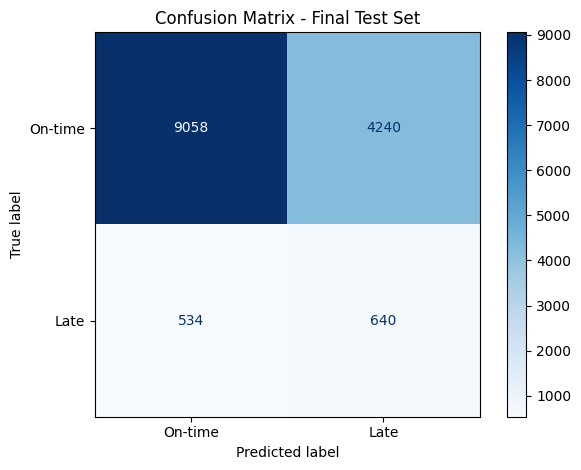

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["On-time", "Late"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Final Test Set")
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

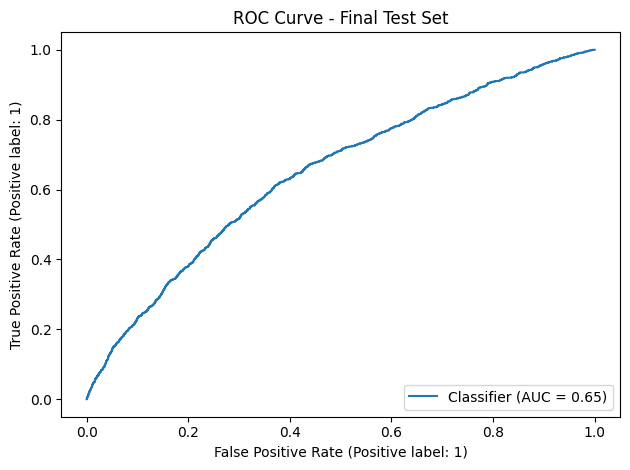

In [32]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba
)

plt.title("ROC Curve - Final Test Set")
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

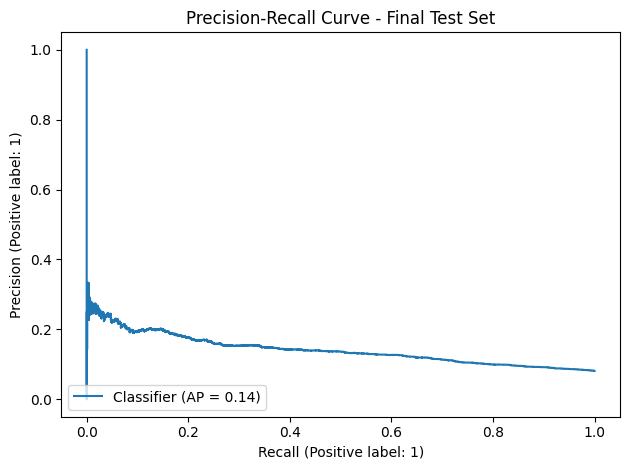

In [33]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_proba
)

plt.title("Precision-Recall Curve - Final Test Set")
plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

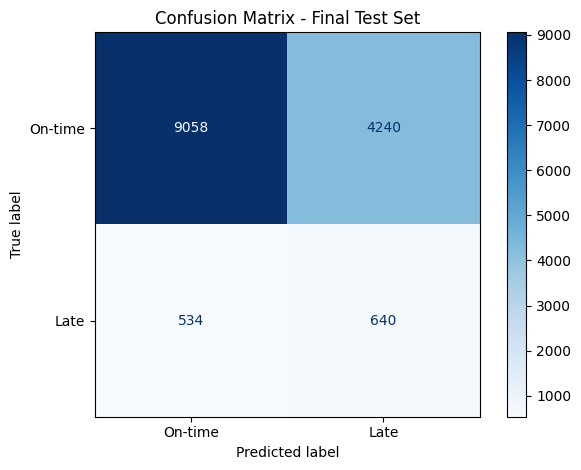

In [34]:
plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["On-time", "Late"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Final Test Set")
plt.tight_layout()

plt.savefig(
    "features/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 700x500 with 0 Axes>

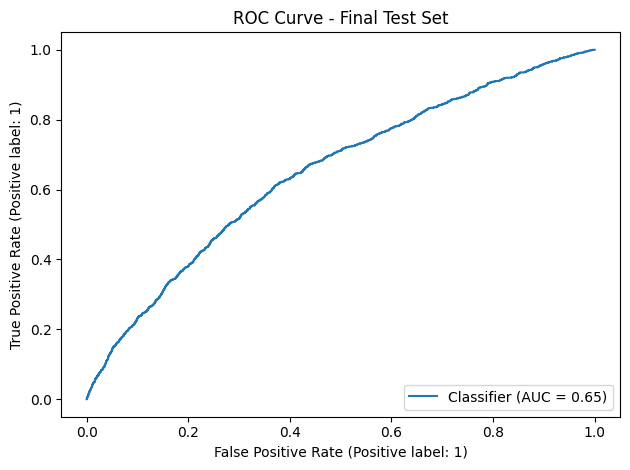

In [35]:
plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba
)

plt.title("ROC Curve - Final Test Set")
plt.tight_layout()

plt.savefig(
    "features/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 700x500 with 0 Axes>

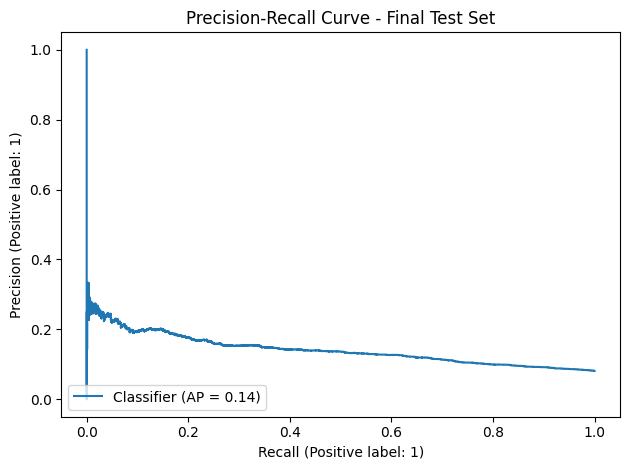

In [36]:
plt.figure(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_proba
)

plt.title("Precision-Recall Curve - Final Test Set")
plt.tight_layout()

plt.savefig(
    "features/precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
model_summary = {
    "model": "Logistic Regression",
    "best_C": 0.10,
    "class_weight": "balanced",
    "n_features": X_train_processed.shape[1],
    "train_samples": X_train_processed.shape[0],
    "validation_samples": X_val_processed.shape[0],
    "test_samples": X_test_processed.shape[0],
    "validation_f1": best_val_f1,
    "test_accuracy": test_accuracy,
    "test_precision": test_precision,
    "test_recall": test_recall,
    "test_f1": test_f1,
    "test_roc_auc": test_roc_auc,
    "test_pr_auc": test_pr_auc
}

model_summary_df = pd.DataFrame([model_summary])

model_summary_df.to_csv(
    "features/model_summary.csv",
    index=False
)

model_summary_df

,model,best_C,class_weight,n_features,train_samples,validation_samples,test_samples,validation_f1,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
0,Logistic Regression,0.1,balanced,3701,67533,14471,14472,0.205748,0.670122,0.131148,0.545145,0.21143,0.648662,0.141606


In [38]:
from sklearn.ensemble import RandomForestClassifier

In [39]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [40]:
y_val_pred_rf = rf_model.predict(X_val_processed)
y_val_proba_rf = rf_model.predict_proba(X_val_processed)[:, 1]

rf_accuracy = accuracy_score(y_val, y_val_pred_rf)
rf_precision = precision_score(y_val, y_val_pred_rf, zero_division=0)
rf_recall = recall_score(y_val, y_val_pred_rf, zero_division=0)
rf_f1 = f1_score(y_val, y_val_pred_rf, zero_division=0)
rf_roc_auc = roc_auc_score(y_val, y_val_proba_rf)
rf_pr_auc = average_precision_score(y_val, y_val_proba_rf)

print("Random Forest - Validation")
print("--------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")
print(f"PR-AUC   : {rf_pr_auc:.4f}")

Random Forest - Validation
--------------------------
Accuracy : 0.9189
Precision: 0.5217
Recall   : 0.0102
F1 Score : 0.0201
ROC-AUC  : 0.6347
PR-AUC   : 0.1433


In [41]:
print(classification_report(
    y_val,
    y_val_pred_rf,
    target_names=["On-time", "Late"],
    zero_division=0
))

              precision    recall  f1-score   support

     On-time       0.92      1.00      0.96     13297
        Late       0.52      0.01      0.02      1174

    accuracy                           0.92     14471
   macro avg       0.72      0.50      0.49     14471
weighted avg       0.89      0.92      0.88     14471



In [42]:
# %pip install xgboost

In [43]:
from xgboost import XGBClassifier

In [44]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 11.325789377623654


In [45]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_processed,
    y_train
)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [46]:
y_val_pred_xgb = xgb_model.predict(X_val_processed)
y_val_proba_xgb = xgb_model.predict_proba(X_val_processed)[:, 1]

xgb_accuracy = accuracy_score(y_val, y_val_pred_xgb)
xgb_precision = precision_score(y_val, y_val_pred_xgb, zero_division=0)
xgb_recall = recall_score(y_val, y_val_pred_xgb, zero_division=0)
xgb_f1 = f1_score(y_val, y_val_pred_xgb, zero_division=0)
xgb_roc_auc = roc_auc_score(y_val, y_val_proba_xgb)
xgb_pr_auc = average_precision_score(y_val, y_val_proba_xgb)

print("XGBoost - Validation")
print("--------------------")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")
print(f"PR-AUC   : {xgb_pr_auc:.4f}")

XGBoost - Validation
--------------------
Accuracy : 0.6968
Precision: 0.1336
Recall   : 0.4991
F1 Score : 0.2108
ROC-AUC  : 0.6534
PR-AUC   : 0.1517


In [47]:
print(classification_report(
    y_val,
    y_val_pred_xgb,
    target_names=["On-time", "Late"],
    zero_division=0
))

              precision    recall  f1-score   support

     On-time       0.94      0.71      0.81     13297
        Late       0.13      0.50      0.21      1174

    accuracy                           0.70     14471
   macro avg       0.54      0.61      0.51     14471
weighted avg       0.88      0.70      0.76     14471



In [48]:
model_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "precision": best_val_precision,
        "recall": best_val_recall,
        "f1": best_val_f1,
        "roc_auc": best_val_roc_auc,
        "pr_auc": best_val_pr_auc
    },
    {
        "model": "Random Forest",
        "precision": rf_precision,
        "recall": rf_recall,
        "f1": rf_f1,
        "roc_auc": rf_roc_auc,
        "pr_auc": rf_pr_auc
    },
    {
        "model": "XGBoost",
        "precision": xgb_precision,
        "recall": xgb_recall,
        "f1": xgb_f1,
        "roc_auc": xgb_roc_auc,
        "pr_auc": xgb_pr_auc
    }
])

model_comparison.sort_values(
    by="f1",
    ascending=False
)

,model,precision,recall,f1,roc_auc,pr_auc
2,XGBoost,0.133607,0.499148,0.210791,0.653416,0.151726
0,Logistic Regression,0.127273,0.536627,0.205748,0.636820,0.138482
1,Random Forest,0.521739,0.010221,0.020050,0.634681,0.143293
